# Vector Search com Digits (MNIST-like) + Qdrant
#
Objetivos:
1. Carregar dataset de dígitos
2. Criar embeddings simples
3. Inserir no Qdrant
4. Fazer busca vetorial
5. Visualizar nearest neighbors
6. Plotar embeddings com PCA

Requisitos:

pip install qdrant-client scikit-learn matplotlib


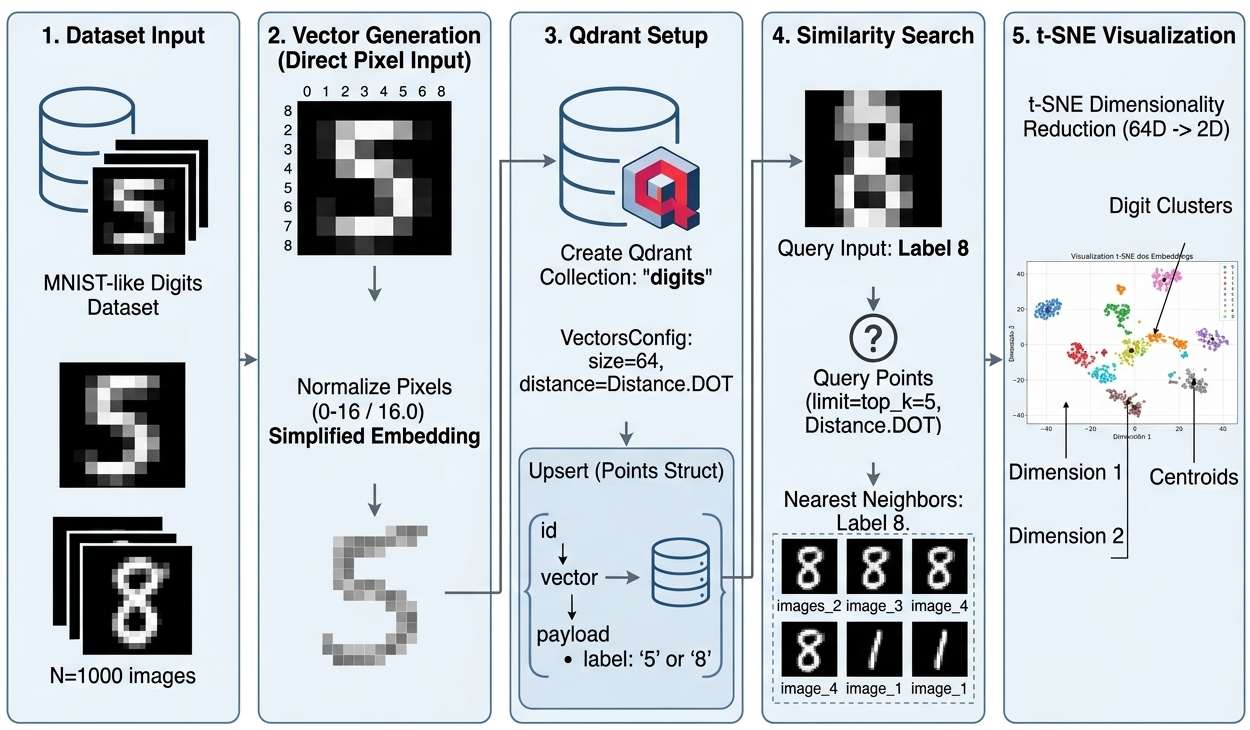

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

from qdrant_client import QdrantClient
from qdrant_client.models import (Distance,VectorParams,PointStruct)

# 1. CARREGAR DATASET

In [2]:
print("Carregando dataset Digits...")

digits = load_digits()

X = digits.data
y = digits.target

images = digits.images

N = 1000 # Usar apenas 1000 imagens

images = images[:N]
targets = y[:N]

Carregando dataset Digits...


# 2. GERAR EMBEDDINGS

Neste exemplo, o embedding é uma representação simplificada da imagem utilizando diretamente os pixels normalizados. 
Em aplicações reais, embeddings normalmente são gerados por modelos de Deep Learning, como CNNs ou Transformers, capazes de aprender representações semânticas mais ricas.

In [3]:
# Cada imagem: # 8x8 -> vetor 64D
embeddings = X[:N] / 16.0 #normalizando pixels das imagens
print(f"Embeddings criados: {embeddings.shape}")

Embeddings criados: (1000, 64)


# 3. CRIAR QDRANT

In [ ]:
#client = QdrantClient(":memory:")
client = QdrantClient(host="localhost", port=6333)

COLLECTION_NAME = "MNIST_digits"
client.recreate_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=64,
        distance=Distance.DOT #EUCLID, DOT, COSINE
    )
)
 
print("Collection criada!")

Collection criada!


/var/folders/__/rsjg1yys7y904vmmv_qqyptr0000gn/T/ipykernel_18056/436181541.py:4: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


# 4. INSERIR DADOS

In [5]:
points = []

for i in range(N):

    point = PointStruct(
        id=i,
        vector=embeddings[i].tolist(),
        payload={
            "label": int(targets[i])
        }
    )

    points.append(point)

client.upsert(
    collection_name="digits",
    points=points
)

print("Dados inseridos no Qdrant!")

Dados inseridos no Qdrant!


# 5. FUNÇÃO DE BUSCA

In [6]:
def buscar_similares(idx, top_k=5):

    query_vector = embeddings[idx]

    resultados = client.query_points(
        collection_name="digits",
        query=query_vector.tolist(),
        limit=top_k
    ).points

    print("\n================================================")
    print(f"Buscar: número {targets[idx]}")
    print("================================================")

    # --------------------------------------------------------
    # Mostrar imagem da consulta
    # --------------------------------------------------------

    plt.figure(figsize=(2,2))
    plt.imshow(images[idx], cmap="gray")
    plt.title(f"QUERY: {targets[idx]}")
    plt.axis("off")
    plt.show()

    # --------------------------------------------------------
    # Mostrar resultados
    # --------------------------------------------------------

    fig, axes = plt.subplots(1, top_k, figsize=(8,3))
    for ax, r in zip(axes, resultados):

        rid = r.id

        ax.imshow(images[rid], cmap="gray")
        ax.set_title(f"{targets[rid]}")
        ax.axis("off")

    plt.show()

# 6. CONSULTAS 


Buscar: número 5


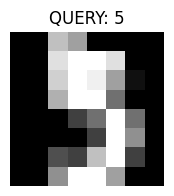

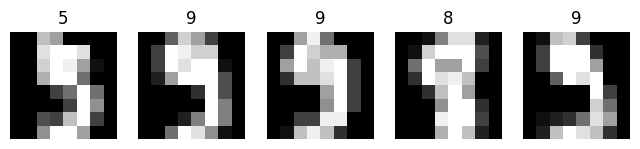


Buscar: número 8


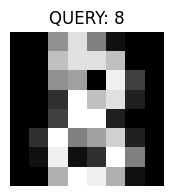

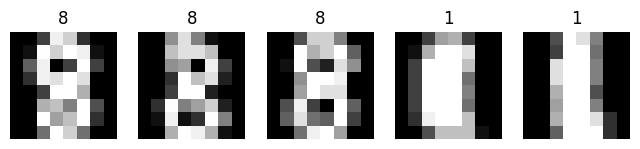

In [7]:
# Buscar um número 5

idx_5 = np.where(targets == 5)[0][0]
buscar_similares(idx_5)

# ------------------------------------------------------------
# Buscar um número 8

idx_8 = np.where(targets == 8)[0][0]
buscar_similares(idx_8)

# 7. VISUALIZAÇÃO DOS EMBEDDINGS COM t-SNE


Gerando visualização t-SNE...


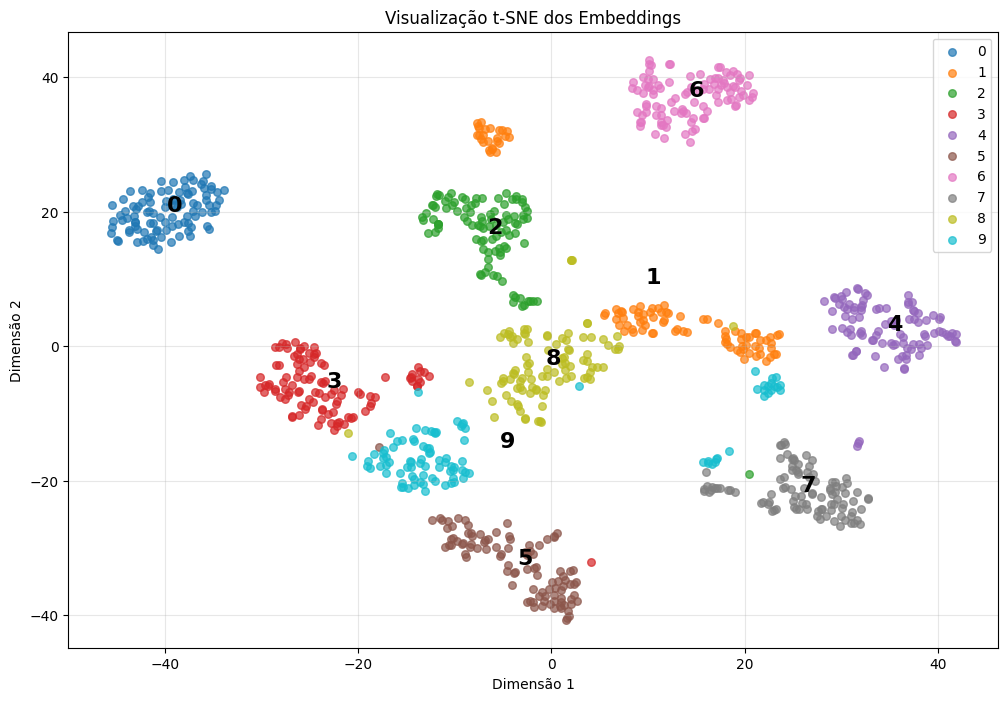

In [8]:
#from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("\nGerando visualização t-SNE...")

tsne = TSNE(n_components=2,perplexity=30,random_state=42)

reduced = tsne.fit_transform(embeddings)
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(12,8))
for digit in range(10):

    idxs = targets == digit
    plt.scatter(reduced[idxs, 0],reduced[idxs, 1],s=30,alpha=0.7,label=f"{digit}")
 
    # Centróide
    cx = reduced[idxs, 0].mean()
    cy = reduced[idxs, 1].mean()
    plt.text(cx,cy,str(digit),fontsize=16,weight='bold')
 
plt.title("Visualização t-SNE dos Embeddings")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()